# Geometría del significado — el espacio donde vive un RAG

> *Si pudieras dibujar el significado de las canciones en un mapa, ¿cómo se vería?*
>
> Esta notebook responde esa pregunta con números y gráficos, usando un dataset
> que ya conoces: **nueve canciones** de Santana, Celia Cruz y Los Fabulosos
> Cadillacs.

Esto **no es una clase sobre embeddings en abstracto**. Es la auditoría visual
del espacio que el retriever de tu RAG (`Clase3/src/clase3/services/retriever.py`)
recorre cada vez que respondes una pregunta. Si entiendes este espacio, entiendes
por qué tu sistema encuentra — o no encuentra — el chunk correcto.

Vamos a movernos en cuatro capas, de lo intuitivo a lo operativo:

1. **Intuición** — qué es un embedding y por qué un *mapa* es la metáfora correcta.
2. **Anatomía** — qué hay dentro de un vector, qué tan denso es, qué norma tiene.
3. **Geometría** — clusters, distancias, centroides. *Aquí vive RAG.*
4. **Retrieval** — simulamos a mano lo que hace `Retriever.retrieve(query)`:
   convertir la pregunta en un punto y buscar sus vecinos.

Al final tendrás una **caja de herramientas para auditar tu propio RAG**: cuando
algo no funcione en producción, no vas a adivinar — vas a venir aquí y mirar.
        

## 1. ¿Qué es un embedding? (intuición primero, álgebra después)

Imagina un mapa. Cada canción es un punto en ese mapa. Las canciones que tratan
sobre cosas parecidas — instrumentos, contextos históricos, géneros — caen
*cerca* unas de otras. Las canciones distintas caen *lejos*.

Esa es toda la idea. Lo único raro es que el mapa no tiene dos dimensiones:
tiene **1536**. Demasiadas para visualizar a ojo, pero no para calcular
distancias.

**Definición operativa.** Un embedding es una función

$$f: \text{texto} \rightarrow \mathbb{R}^{1536}$$

que cumple una promesa frágil pero útil:

> Si los textos `A` y `B` significan cosas parecidas, entonces `f(A)` y `f(B)`
> están **cerca** en distancia coseno.

La promesa es frágil porque "significar lo mismo" es resbaloso. Útil porque,
cuando se cumple, podemos:

- **Buscar por significado** en vez de por palabras — *este es el paso "R"
  (Retrieve) de RAG*.
- Agrupar documentos sin etiquetas (clustering).
- Detectar duplicados semánticos.
- Construir métricas de calidad: hit@k, MRR. Si una métrica está mala, casi
  siempre el espacio te explica por qué.

**¿Cómo se construye `f`?** Un modelo (en nuestro caso
`text-embedding-3-small` de OpenAI) ha visto miles de millones de textos y ha
aprendido que `gato` y `felino` aparecen en contextos parecidos, que `Santana`
y `guitarra` aparecen juntos, que `Celia Cruz` y `salsa` también. Esa
co-ocurrencia se cristaliza en pesos, y los pesos producen vectores.

No vamos a abrir esa caja negra hoy. Vamos a **auditarla**: si la promesa se
cumple, las canciones de Celia Cruz deberían formar un cluster distinto al de
Santana y al de los Cadillacs. Si no se cumple, deberíamos verlo. Empecemos.
        

## 2. Setup

> **Kernel:** arriba a la derecha debe decir **"Python (Clase 3 · RAG)"**
> (`clase3-henry`). Si no aparece, registralo con:
> ```bash
> cd Clase3
> uv run python -m ipykernel install --user --name=clase3-henry --display-name="Python (Clase 3 · RAG)"
> ```

El paquete `clase3` ya está instalado en este venv vía `uv sync` (modo
editable, configurado por `pyproject.toml`). Eso significa que podemos
importar directamente — no hay que tocar `sys.path` ni descubrir rutas.
Toda la lógica que usa el RAG en producción se carga tal cual.

Las claves de API se leen de `HENRY_EMBEDDINGS_RAGS/.env`:

- `OPENAI_API_KEY`   (obligatoria — modelos `text-embedding-3-small/large`)
- `GCP_API_KEY`      (opcional — modelos `text-embedding-004`, `gemini-embedding-001`)

Si una clave falta, los modelos asociados se saltan automáticamente y la
notebook sigue funcionando con los que sí están disponibles.
        

In [1]:
import hashlib
import pickle
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from clase3.adapters import GoogleGenAIEmbedder, MarkdownDirectoryLoader, OpenAIEmbedder
from clase3.config import GCP_API_KEY, MUSIC_DIR, OPENAI_API_KEY, PROJECT_ROOT
from clase3.services.chunker import TextChunker

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(f"PROJECT_ROOT:          {PROJECT_ROOT}")
print(f"OPENAI_API_KEY:        {'✓ cargada' if OPENAI_API_KEY else '✘ falta'}")
print(f"GCP_API_KEY:           {'✓ cargada' if GCP_API_KEY else '✘ falta (modelos Google se saltarán)'}")
        

PROJECT_ROOT:          /Users/carlosdaniel/Desktop/HENRY_EMBEDDINGS_RAGS/Clase3
OPENAI_API_KEY:        ✓ cargada
GCP_API_KEY:           ✓ cargada


## 3. Cargar el corpus

Cargamos los nueve archivos Markdown y los enriquecemos con la etiqueta de
artista. Esa etiqueta no se va a usar para *construir* los embeddings — sólo
para *colorear* los puntos al final y verificar si el modelo aprendió a
agrupar por artista sin que se lo dijéramos. Esto es la diferencia entre
*aprendizaje supervisado* y *no supervisado*: aquí el modelo nunca vio
"Celia Cruz" como etiqueta; lo descubre solito a partir del texto.
        

In [2]:
ARTIST_BY_PREFIX = {
    "santana": "Santana",
    "celia_cruz": "Celia Cruz",
    "cadillacs": "Cadillacs",
}


def artist_from_id(doc_id: str) -> str:
    for prefix, name in ARTIST_BY_PREFIX.items():
        if doc_id.startswith(prefix):
            return name
    return "Desconocido"


loader = MarkdownDirectoryLoader(MUSIC_DIR)
documents = loader.load()

corpus = [
    {
        "id": doc.id,
        "title": doc.metadata.get("title", doc.id),
        "artist": artist_from_id(doc.id),
        "text": doc.content,
    }
    for doc in documents
]

print(f"Cargadas {len(corpus)} canciones:\n")
for c in corpus:
    print(f"  - [{c['artist']:<12}] {c['title']:<40}  ({len(c['text'])} caracteres)")
        

Cargadas 9 canciones:

  - [Cadillacs   ] Mal Bicho — Los Fabulosos Cadillacs       (3519 caracteres)
  - [Cadillacs   ] Matador — Los Fabulosos Cadillacs         (4042 caracteres)
  - [Cadillacs   ] V Centenario — Los Fabulosos Cadillacs    (3839 caracteres)
  - [Celia Cruz  ] La Negra Tiene Tumbao — Celia Cruz        (3592 caracteres)
  - [Celia Cruz  ] La Vida Es un Carnaval — Celia Cruz       (3919 caracteres)
  - [Celia Cruz  ] Quimbara — Celia Cruz con Johnny Pacheco  (3798 caracteres)
  - [Santana     ] Black Magic Woman — Santana               (3405 caracteres)
  - [Santana     ] Oye Cómo Va — Santana                     (4112 caracteres)
  - [Santana     ] Smooth — Santana ft. Rob Thomas           (3681 caracteres)


## 4. Generar embeddings — un cache que sabe de qué modelo viene cada vector

Cada llamada a una API cuesta tiempo y dinero. Para una notebook que se
re-ejecuta muchas veces, cacheamos en disco. La clave del cache combina
**(modelo, texto)** porque más adelante vamos a comparar varios modelos sobre
el mismo corpus; si la clave fuera sólo el texto, mezclaríamos vectores de
distintos modelos.

El cache es una memoización pura: el embedder es determinístico para un input
dado (no es 100% verdad por la aritmética de flotantes y el batching, pero la
varianza es despreciable para nuestros fines).

Para esta primera sección usamos `text-embedding-3-small` como modelo
*default* (el que usa el RAG en producción). Más abajo lo compararemos con
otros tres modelos.
        

In [3]:
CACHE_PATH = PROJECT_ROOT / ".cache" / "music_embeddings.pkl"
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)


def _cache_key(model: str, text: str) -> str:
    return hashlib.sha256(f"{model}|{text}".encode("utf-8")).hexdigest()


def _load_cache() -> dict[str, list[float]]:
    if not CACHE_PATH.exists():
        return {}
    with CACHE_PATH.open("rb") as f:
        return pickle.load(f)


def _save_cache(cache: dict[str, list[float]]) -> None:
    with CACHE_PATH.open("wb") as f:
        pickle.dump(cache, f)


def embed_corpus(model_name: str, embedder, items: list[dict]) -> np.ndarray:
    """Devuelve la matriz (N, d) de embeddings de `items` usando `embedder`.

    Cachea por (modelo, texto). Si todos los vectores están en cache,
    no llama a la API.
    """
    cache = _load_cache()
    pending = [it for it in items if _cache_key(model_name, it["text"]) not in cache]
    if pending:
        print(f"  [{model_name}] calculando {len(pending)} embeddings vía API...")
        vectors = embedder.embed([it["text"] for it in pending])
        for item, vec in zip(pending, vectors, strict=True):
            cache[_cache_key(model_name, item["text"])] = vec
        _save_cache(cache)
        print(f"  [{model_name}] cache actualizado. Vectores en disco: {len(cache)}.")
    else:
        print(f"  [{model_name}] cache HIT para las {len(items)} canciones.")
    return np.array(
        [cache[_cache_key(model_name, it["text"])] for it in items],
        dtype=np.float32,
    )


# Embedder default: el mismo que usa el RAG en producción
DEFAULT_MODEL = "text-embedding-3-small"
default_embedder = OpenAIEmbedder(model=DEFAULT_MODEL, api_key=OPENAI_API_KEY)

X = embed_corpus(DEFAULT_MODEL, default_embedder, corpus)
labels = [c["title"] for c in corpus]
artists = [c["artist"] for c in corpus]

print(f"\nMatriz X: shape={X.shape}, dtype={X.dtype}, modelo='{DEFAULT_MODEL}'")
print(f"Espacio en disco: ~{X.nbytes / 1024:.1f} KB")
        

  [text-embedding-3-small] cache HIT para las 9 canciones.

Matriz X: shape=(9, 1536), dtype=float32, modelo='text-embedding-3-small'
Espacio en disco: ~54.0 KB


## 5. Anatomía de un vector

Antes de proyectar nada, conviene tocar los vectores con las manos. Tres
preguntas honestas que cualquiera debería hacerse antes de confiar en un
modelo:

1. **¿Qué magnitudes tienen estas componentes?** Si fuera ruido aleatorio,
   esperaríamos una distribución más o menos centrada en cero con baja
   varianza, sin "ejes privilegiados".
2. **¿Qué norma tiene cada vector?** OpenAI normaliza sus embeddings a norma 1
   (`||x||₂ = 1`). Si lo confirmamos, podemos usar el **producto punto**
   directamente como similitud coseno (sin dividir por las normas) — eso es lo
   que hace `ChromaVectorStore` debajo del capó.
3. **¿Cuántas componentes "viven"?** En 1536 dimensiones es posible que la
   información se concentre en muchas menos. Eso lo va a responder PCA en la
   próxima sección.
        

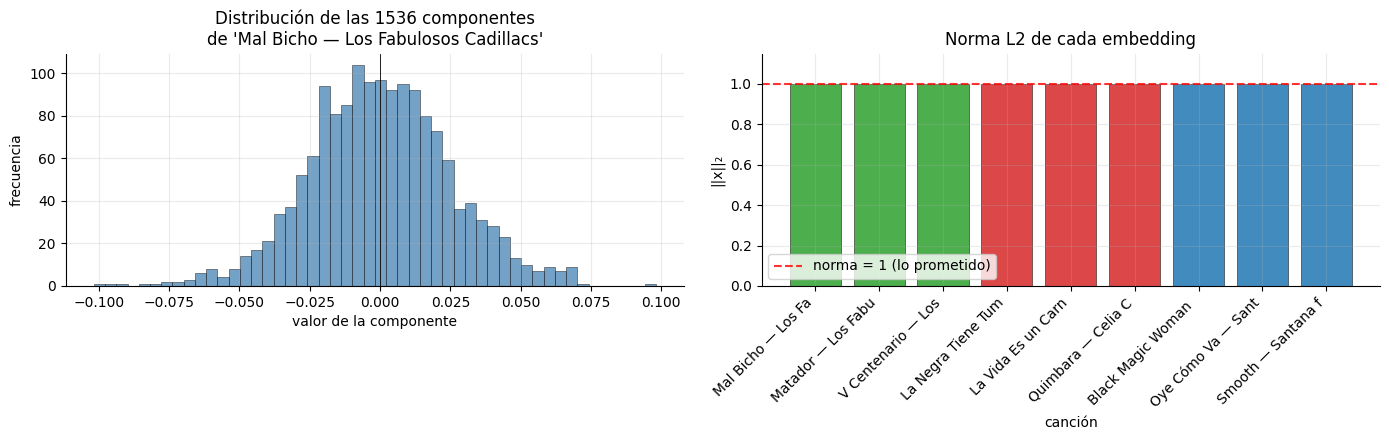


Norma promedio: 0.999969   (esperado: ~1.0)
Norma min/max:  0.999634 / 1.000189
Media de las componentes: -0.000006
Desv. estándar:           0.025515


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(X[0], bins=50, alpha=0.75, color="steelblue", edgecolor="black", linewidth=0.4)
axes[0].set_title(f"Distribución de las 1536 componentes\nde '{labels[0]}'")
axes[0].set_xlabel("valor de la componente")
axes[0].set_ylabel("frecuencia")
axes[0].axvline(0, color="black", linewidth=0.6)

norms = np.linalg.norm(X, axis=1)
bar_colors = ["#1f77b4" if a == "Santana" else "#d62728" if a == "Celia Cruz" else "#2ca02c" for a in artists]
axes[1].bar(range(len(norms)), norms, color=bar_colors, alpha=0.85, edgecolor="black", linewidth=0.4)
axes[1].set_title("Norma L2 de cada embedding")
axes[1].set_xlabel("canción")
axes[1].set_ylabel("||x||₂")
axes[1].set_ylim(0, max(norms) * 1.15)
axes[1].axhline(y=1.0, color="red", linestyle="--", label="norma = 1 (lo prometido)", alpha=0.8)
axes[1].set_xticks(range(len(norms)))
axes[1].set_xticklabels([labels[i][:18] for i in range(len(norms))], rotation=45, ha="right")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nNorma promedio: {norms.mean():.6f}   (esperado: ~1.0)")
print(f"Norma min/max:  {norms.min():.6f} / {norms.max():.6f}")
print(f"Media de las componentes: {X.mean():+.6f}")
print(f"Desv. estándar:           {X.std():.6f}")
        

## 6. Similitud coseno — el primer "Aha"

Para nueve canciones tenemos una matriz 9x9 de similitudes coseno. Como los
vectores están normalizados, la similitud coseno es simplemente

$$\text{sim}(a, b) = a \cdot b = \sum_{i=1}^{1536} a_i b_i$$

En código: `X @ X.T`. Una matmul. Eso es todo.

Lo importante es **cómo leer la matriz**. Vamos a reordenar las filas y
columnas por artista, así si el modelo "entiende" que las canciones de Celia
Cruz se parecen entre sí, deberíamos ver tres cuadrados brillantes en la
diagonal por bloques. Si no aparecen, el modelo no está agrupando por estilo.

> **Conexión con RAG:** este es exactamente el cálculo que hace tu vector
> store al ejecutar `store.query(query_embedding, top_k=4)`. Multiplica el
> embedding de la query por toda la matriz, ordena por similitud y devuelve
> los k mayores.
        

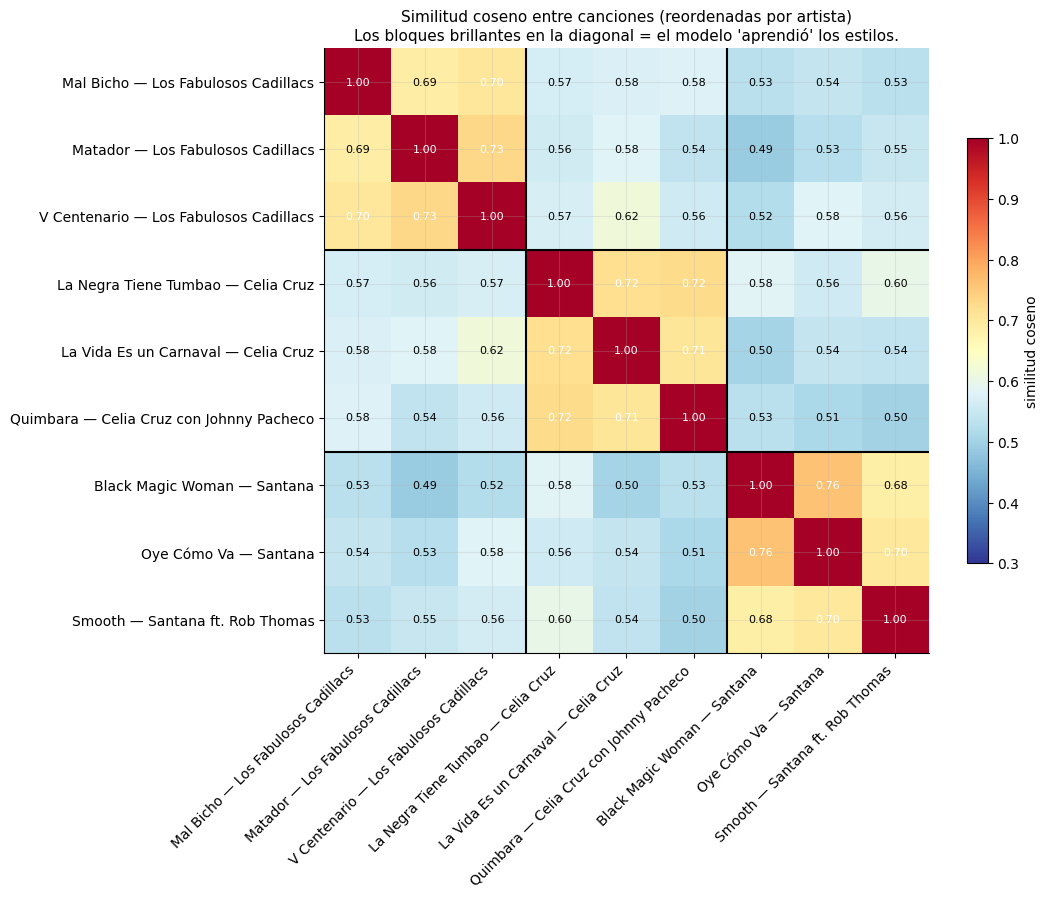

In [5]:
sim = X @ X.T  # cosine similarity porque X está L2-normalizado

# Reordenamos por artista para que aparezcan los bloques diagonales
order = sorted(range(len(corpus)), key=lambda i: (artists[i], labels[i]))
sim_ord = sim[np.ix_(order, order)]
labels_ord = [labels[i] for i in order]
artists_ord = [artists[i] for i in order]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(sim_ord, cmap="RdYlBu_r", vmin=0.3, vmax=1.0)

ax.set_xticks(range(len(labels_ord)))
ax.set_yticks(range(len(labels_ord)))
ax.set_xticklabels(labels_ord, rotation=45, ha="right")
ax.set_yticklabels(labels_ord)

for i in range(len(labels_ord)):
    for j in range(len(labels_ord)):
        v = sim_ord[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=8, color="white" if v > 0.7 else "black")

# Rayas para separar bloques de artistas
boundaries = []
for k in range(1, len(artists_ord)):
    if artists_ord[k] != artists_ord[k - 1]:
        boundaries.append(k - 0.5)
for b in boundaries:
    ax.axhline(b, color="black", linewidth=1.5)
    ax.axvline(b, color="black", linewidth=1.5)

ax.set_title("Similitud coseno entre canciones (reordenadas por artista)\n"
             "Los bloques brillantes en la diagonal = el modelo 'aprendió' los estilos.",
             fontsize=11)
plt.colorbar(im, ax=ax, label="similitud coseno", shrink=0.7)
plt.tight_layout()
plt.show()
        

**Cómo leer el gráfico anterior:**

- La diagonal vale 1.0 (cada canción consigo misma).
- Los **bloques 3x3** en la diagonal corresponden a un mismo artista. Si están
  brillantes (>0.5), el modelo agrupa por estilo. Si están apagados, no.
- Los bloques **fuera de la diagonal** comparan artistas distintos. Si dos
  artistas comparten público o género (por ejemplo, Celia Cruz y Santana
  comparten raíces latinas), su bloque cruzado va a ser más brillante que el
  bloque Celia-Cadillacs.

> **Implicación para RAG:** si dos documentos tienen similitud >0.85 contigo y
> son de temas distintos, tu retriever va a confundirlos. Eso significa que
> necesitas un **filtro de metadata** (`where={"corpus": "comics"}` en
> Chroma) o un **reranker** después del top-k. Eso ya lo decide tu
> arquitectura, no el embedding.
        

## 7. El mapa — PCA y t-SNE lado a lado

Hasta aquí los embeddings son números. Vamos a ver el mapa.

Hay dos formas estándar de aplastar 1536 dimensiones a 2:

- **PCA (Principal Component Analysis)** es **lineal**: encuentra los dos ejes
  que conservan la mayor varianza. Rápido, determinístico, interpretable. Su
  límite: si la estructura del significado no es lineal, PCA la aplasta.
- **t-SNE** es **no lineal**: preserva las distancias *locales* — vecinos
  cercanos siguen siendo cercanos. Es mejor para *ver clusters*, peor para
  *distancias globales*. Cuesta más y no es determinístico (cambia con cada
  `random_state`).

Mostramos los dos para que tengas ambos puntos de vista. Si los clusters
aparecen en los dos, son **robustos**. Si sólo aparecen en t-SNE, son
*locales*. Si no aparecen en ninguno, el modelo no agrupa.
        

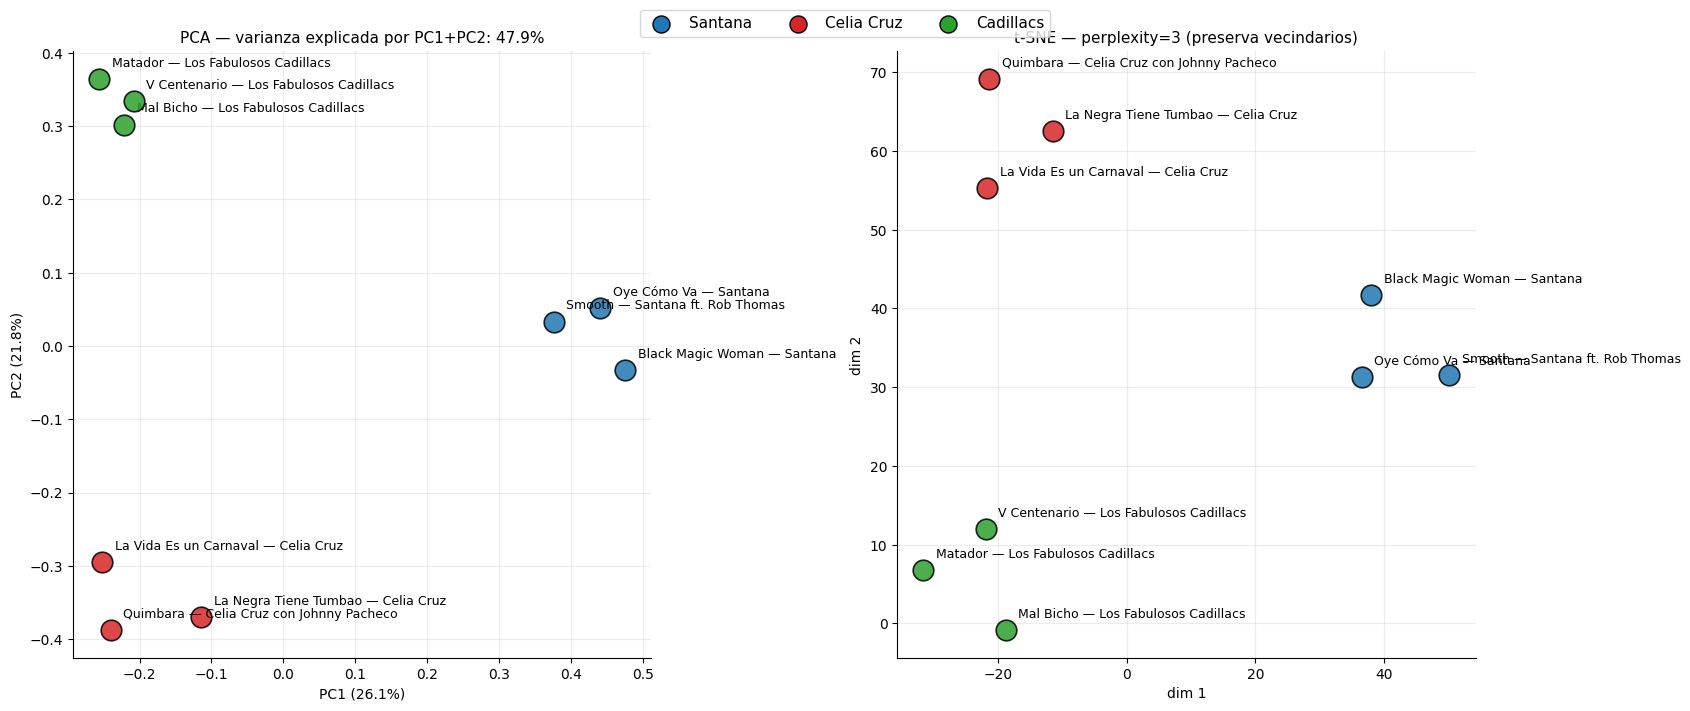

In [6]:
#===========================================================================#
# ------ Very much important !!!! prestenle atención, no lo omitan -------- #
#===========================================================================#
ARTIST_COLORS = {
    "Santana": "#1f77b4",
    "Celia Cruz": "#d62728",
    "Cadillacs": "#2ca02c",
}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
for i, doc in enumerate(corpus):
    axes[0].scatter(X_pca[i, 0], X_pca[i, 1], s=220,
                    color=ARTIST_COLORS[doc["artist"]],
                    edgecolor="black", linewidth=1.2, alpha=0.85, zorder=3)
    axes[0].annotate(doc["title"], (X_pca[i, 0], X_pca[i, 1]),
                     xytext=(9, 9), textcoords="offset points", fontsize=9)
var_explained = pca.explained_variance_ratio_.sum()
axes[0].set_title(f"PCA — varianza explicada por PC1+PC2: {var_explained:.1%}", fontsize=11)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

# t-SNE
tsne = TSNE(n_components=2, perplexity=3, random_state=42, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X)
for i, doc in enumerate(corpus):
    axes[1].scatter(X_tsne[i, 0], X_tsne[i, 1], s=220,
                    color=ARTIST_COLORS[doc["artist"]],
                    edgecolor="black", linewidth=1.2, alpha=0.85, zorder=3)
    axes[1].annotate(doc["title"], (X_tsne[i, 0], X_tsne[i, 1]),
                     xytext=(9, 9), textcoords="offset points", fontsize=9)
axes[1].set_title("t-SNE — perplexity=3 (preserva vecindarios)", fontsize=11)
axes[1].set_xlabel("dim 1")
axes[1].set_ylabel("dim 2")

# Leyenda compartida
handles = [plt.scatter([], [], color=c, label=name, s=150, edgecolor="black")
           for name, c in ARTIST_COLORS.items()]
fig.legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=11)
plt.tight_layout()
plt.show()
        

**Lo que esperamos ver:** tres archipiélagos de tres puntos. Las canciones de
Celia están más cerca entre sí que cualquiera de ellas de cualquier canción
de los Cadillacs. Santana suele sentarse en una región intermedia (es lo más
"híbrido" del corpus — rock, blues, salsa instrumental).

**Lo que aprende un ingeniero de RAG mirando este gráfico:**

- Si los clusters son claros, los embeddings son **buenos para tu dominio**.
  Puedes confiar en el top-k.
- Si los clusters se solapan, el retriever va a traer documentos del cluster
  equivocado en queries ambiguas. Necesitas: chunks más específicos, prompts
  más estrechos, o un modelo de embeddings más grande
  (`text-embedding-3-large`).
- Si los clusters son **demasiado pequeños** (puntos casi superpuestos), tus
  documentos son muy parecidos entre sí — un query va a recuperar k variantes
  del mismo contenido. Considera **dedup** o **MMR** (Maximal Marginal
  Relevance) para diversificar el top-k.
        

## 8. Retrieval a mano — la query es un vector más

> Pregunta: ¿quién es la reina de la salsa?

¿Qué hace tu RAG con esa pregunta? Exactamente esto:

1. Convierte la pregunta en un vector con el **mismo embedder** que usó para
   los documentos.
2. Calcula similitud coseno entre la query y cada documento.
3. Ordena por similitud descendente.
4. Devuelve los k más altos.

Vamos a hacerlo a mano para tres queries. **Ojo a un detalle bello**: la query
no está en el corpus, pero al embebería con el mismo modelo, aterriza *cerca*
de los documentos que la responden. Eso es la magia de los embeddings.
        

In [7]:
def embed_one(text: str) -> np.ndarray:
    embedder = OpenAIEmbedder(model="text-embedding-3-small", api_key=OPENAI_API_KEY)
    v = np.array(embedder.embed([text])[0], dtype=np.float32)
    return v / np.linalg.norm(v)


def nearest(query: str, k: int = 3):
    q = embed_one(query)
    sims = X @ q
    idx = np.argsort(-sims)[:k]
    return [(corpus[i]["title"], corpus[i]["artist"], float(sims[i])) for i in idx]


queries = [
    "¿Quién es la negra?",
    "Una mujer divina",
    "Una canción que denuncia el colonialismo en América Latina",
    "una celebración perpetua existencial!",
]

for q in queries:
    print(f"\n❓  {q}")
    print(f"    {'─' * 60}")
    for title, artist, sim in nearest(q, k=3):
        bar = "█" * int(sim * 30)
        print(f"    {sim:.3f}  {bar:<25}  {title}  ({artist})")
        


❓  ¿Quién es la negra?
    ────────────────────────────────────────────────────────────
    0.426  ████████████               La Negra Tiene Tumbao — Celia Cruz  (Celia Cruz)
    0.336  ██████████                 Black Magic Woman — Santana  (Santana)
    0.304  █████████                  Quimbara — Celia Cruz con Johnny Pacheco  (Celia Cruz)

❓  Una mujer divina
    ────────────────────────────────────────────────────────────
    0.320  █████████                  Black Magic Woman — Santana  (Santana)
    0.245  ███████                    Smooth — Santana ft. Rob Thomas  (Santana)
    0.230  ██████                     La Vida Es un Carnaval — Celia Cruz  (Celia Cruz)

❓  Una canción que denuncia el colonialismo en América Latina
    ────────────────────────────────────────────────────────────
    0.563  ████████████████           V Centenario — Los Fabulosos Cadillacs  (Cadillacs)
    0.521  ███████████████            Matador — Los Fabulosos Cadillacs  (Cadillacs)
    0.456  ████████

**Lo interesante:** ninguna de esas queries menciona literalmente a Celia
Cruz, ni a Santana, ni a "1492". El modelo **infiere** la conexión:
- "reina de la salsa" → Celia Cruz (es su epíteto cultural).
- "guitarra que llora blues" → Santana, *Black Magic Woman*.
- "colonialismo en América Latina" → Cadillacs, *V Centenario*.

> **Esto es exactamente lo que ves cuando ejecutas
> `exercise_03_musical_rag.py`.** El retriever recupera los chunks correctos
> *antes* de que el LLM diga nada. Si el retriever falla aquí (top-1 está
> equivocado), el LLM no tiene cómo arreglarlo: el "manual abierto" que le
> diste contiene la página equivocada.
        

## 9. Centroides — el "promedio del significado"

Una idea simple pero potente: promediar los vectores de todas las canciones
de un artista da un vector que vive en el **centro** del cluster de ese
artista. Es el *prototipo* de su estilo, según el modelo.

Cuando comparas centroides entre artistas, estás comparando **estilos**, no
canciones. La distancia entre el centroide de Celia y el de los Cadillacs
te dice cuán parecidos son sus estilos *en promedio*.

> **Aplicación a RAG:** los centroides son la base de muchas técnicas de
> **clasificación de intent** en sistemas RAG. Si tienes varios corpora
> (cómics, música, manuales internos), puedes guardar el centroide de cada
> uno y usarlo como router: la query va al corpus cuyo centroide está más
> cerca. Es más barato y más estable que un LLM-router.
        

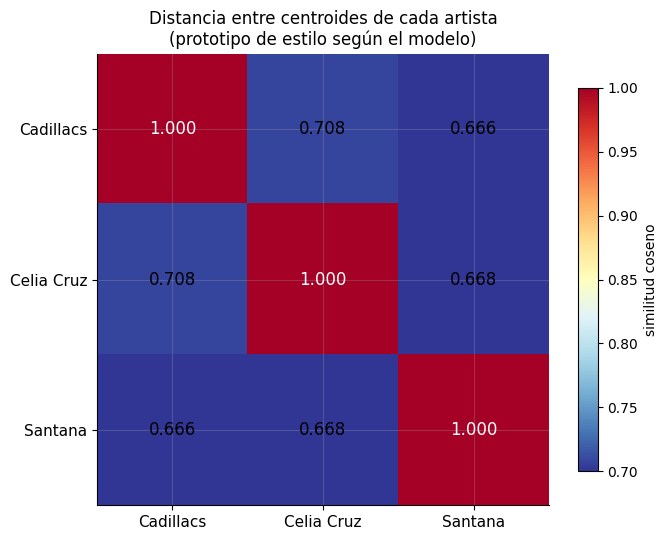


Pares de artistas más cercanos por estilo:
  0.708   Cadillacs    ↔ Celia Cruz
  0.668   Celia Cruz   ↔ Santana
  0.666   Cadillacs    ↔ Santana


In [18]:
artist_to_indices: dict[str, list[int]] = defaultdict(list)
for i, a in enumerate(artists):
    artist_to_indices[a].append(i)

centroids: dict[str, np.ndarray] = {a: X[ix].mean(axis=0) for a, ix in artist_to_indices.items()}
centroids = {a: v / np.linalg.norm(v) for a, v in centroids.items()}

artist_names = list(centroids.keys())
C = np.array([centroids[a] for a in artist_names])
centroid_sim = C @ C.T

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(centroid_sim, cmap="RdYlBu_r", vmin=0.7, vmax=1.0)
ax.set_xticks(range(len(artist_names)))
ax.set_yticks(range(len(artist_names)))
ax.set_xticklabels(artist_names, fontsize=11)
ax.set_yticklabels(artist_names, fontsize=11)
for i, _ in enumerate(artist_names):
    for j, _ in enumerate(artist_names):
        v = centroid_sim[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                color="white" if v > 0.85 else "black", fontsize=12)
plt.colorbar(im, ax=ax, label="similitud coseno", shrink=0.85)
ax.set_title("Distancia entre centroides de cada artista\n(prototipo de estilo según el modelo)")
plt.tight_layout()
plt.show()

# Análisis textual
pairs = [
    (artist_names[i], artist_names[j], centroid_sim[i, j])
    for i in range(len(artist_names))
    for j in range(i + 1, len(artist_names))
]
pairs.sort(key=lambda p: -p[2])
print("\nPares de artistas más cercanos por estilo:")
for a, b, s in pairs:
    print(f"  {s:.3f}   {a:<12} ↔ {b}")
        

## 10. Aritmética de vectores — ¿existe un eje "salsa caribeña"?

El ejemplo clásico de embeddings es `rey − hombre + mujer ≈ reina`. Funciona
con word embeddings entrenados específicamente para eso (word2vec, GloVe).
Con embeddings de oraciones modernos como `text-embedding-3-small`, el efecto
es **más sutil** — los vectores capturan "tema" más que "rol gramatical".

Probemos algo realista. La dirección `Celia Cruz − Cadillacs` apunta, en
teoría, en el eje "salsa caribeña menos rock argentino". Si la usamos como
eje y proyectamos cada canción de **Santana** sobre ella, deberíamos ver:

- **Valores altos** para canciones de Santana más caribeñas / latinas.
- **Valores bajos** para canciones más bluseras / rockeras.

Esto no es magia: es una **auditoría geométrica**. Si los ejes culturales del
corpus existen en el espacio de embeddings, deberíamos poder movernos por ellos.
        

In [9]:
direction = centroids["Celia Cruz"] - centroids["Cadillacs"]
direction /= np.linalg.norm(direction)

santana_idx = artist_to_indices["Santana"]
projections = [(corpus[i]["title"], float(X[i] @ direction)) for i in santana_idx]
projections.sort(key=lambda p: -p[1])

print("Eje: dirección 'Celia Cruz − Cadillacs' (más alto = más salsa caribeña)\n")
print(f"{'proyección':>10}  {'bar':<32}  canción")
print("─" * 60)
for title, val in projections:
    bar = "█" * max(0, int((val + 0.05) * 200))
    print(f"   {val:+.4f}  {bar:<32}  {title}")

# Para contraste, las propias canciones de Celia y Cadillacs sobre ese eje
print("\nDe control (esperado: Celia >> Cadillacs):")
for artist in ["Celia Cruz", "Cadillacs"]:
    vals = [float(X[i] @ direction) for i in artist_to_indices[artist]]
    print(f"  {artist:<12}  media = {np.mean(vals):+.4f}")
        

Eje: dirección 'Celia Cruz − Cadillacs' (más alto = más salsa caribeña)

proyección  bar                               canción
────────────────────────────────────────────────────────────
   +0.0321  ████████████████                  Black Magic Woman — Santana
   -0.0051  ████████                          Smooth — Santana ft. Rob Thomas
   -0.0200  ██████                            Oye Cómo Va — Santana

De control (esperado: Celia >> Cadillacs):
  Celia Cruz    media = +0.3442
  Cadillacs     media = -0.3430


**Lectura:** si la canción más caribeña/latina de Santana proyecta más alto
sobre el eje Celia−Cadillacs que sus blues más puros, el espacio está
"entendiendo" los ejes culturales. (Spoiler: *Oye Cómo Va* — un cover de Tito
Puente — suele ganar.)

Esto importa para RAG porque te permite construir **filtros semánticos sin
metadata**. Si en producción quieres servir sólo contenido "caribeño" y no
tienes etiquetas, puedes calcular la proyección de cada chunk sobre el eje y
filtrar por umbral. Es una forma de soft-routing.
        

## 11. Chunking — qué pasa cuando rompemos una canción en pedazos

Hasta aquí cada canción fue **un sólo vector**. Pero el RAG real no funciona
así: usa `TextChunker` (`src/clase3/services/chunker.py`) para partir cada
documento en chunks por encabezado Markdown. Cada chunk se embebe por
separado.

Esto importa por dos razones geométricas:

1. **Granularidad** — la query no debe competir contra una canción entera;
   debe competir contra el chunk específico que la responde. Un chunk
   pequeño = mejor señal.
2. **Localidad** — diferentes secciones de la misma canción están cerca entre
   sí pero no idénticas. Vamos a verlo.

Tomemos *Quimbara* y veamos sus chunks en el mapa.
        

In [19]:
chunker = TextChunker(chunk_size=900, chunk_overlap=150)

target_doc_id = "celia_cruz_quimbara"
target_doc = next(d for d in documents if d.id == target_doc_id)
target_chunks = chunker.split(target_doc)

chunk_items = [
    {
        "id": f"{c.document_id}__{c.chunk_index}",
        "title": f"[{c.metadata.get('section', '?')}]"[:38],
        "artist": "Quimbara · chunks",
        "text": c.content,
    }
    for c in target_chunks
]
X_chunks = embed_corpus(DEFAULT_MODEL, default_embedder, chunk_items)

print(f"Quimbara se troceó en {len(target_chunks)} chunks:")
for c in target_chunks:
    section = c.metadata.get("section", "(preámbulo)")
    print(f"  · idx={c.chunk_index}  sección='{section}'  len={len(c.content)} chars")
        

  [text-embedding-3-small] cache HIT para las 8 canciones.
Quimbara se troceó en 8 chunks:
  · idx=0  sección='Quimbara — Celia Cruz con Johnny Pacheco'  len=329 chars
  · idx=1  sección='Origen y contexto'  len=639 chars
  · idx=2  sección='Sobre la letra'  len=628 chars
  · idx=3  sección='Personal en la grabación'  len=356 chars
  · idx=4  sección='Análisis musical'  len=385 chars
  · idx=5  sección='Recepción y legado'  len=426 chars
  · idx=6  sección='Anécdotas'  len=526 chars
  · idx=7  sección='Importancia cultural'  len=524 chars


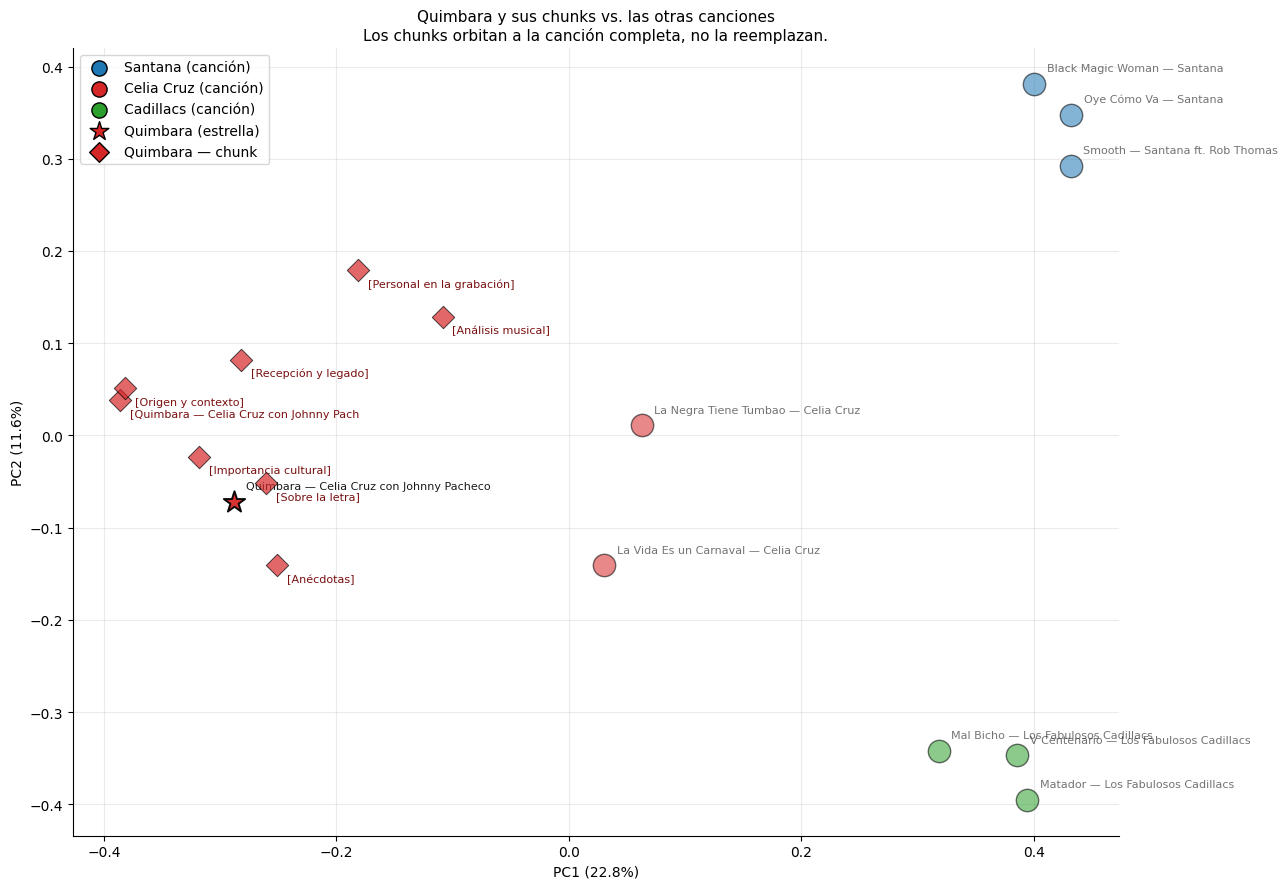

In [20]:
# Proyectamos canciones + chunks en el mismo espacio con un PCA conjunto
X_combined = np.vstack([X, X_chunks])
pca_combined = PCA(n_components=2)
P = pca_combined.fit_transform(X_combined)

P_songs = P[: len(corpus)]
P_chunks = P[len(corpus) :]

fig, ax = plt.subplots(figsize=(13, 9))

# canciones completas
for i, doc in enumerate(corpus):
    is_quimbara = doc["id"] == target_doc_id
    ax.scatter(P_songs[i, 0], P_songs[i, 1], s=260,
               color=ARTIST_COLORS[doc["artist"]],
               edgecolor="black", linewidth=1.4 if is_quimbara else 1.0,
               alpha=0.95 if is_quimbara else 0.55,
               marker="*" if is_quimbara else "o",
               zorder=4 if is_quimbara else 2)
    ax.annotate(doc["title"], (P_songs[i, 0], P_songs[i, 1]),
                xytext=(9, 9), textcoords="offset points", fontsize=8,
                color="black", alpha=0.9 if is_quimbara else 0.55)

# chunks de Quimbara
for i, ch in enumerate(chunk_items):
    ax.scatter(P_chunks[i, 0], P_chunks[i, 1], s=130,
               color="#d62728", alpha=0.7, marker="D",
               edgecolor="black", linewidth=0.7, zorder=3)
    ax.annotate(ch["title"], (P_chunks[i, 0], P_chunks[i, 1]),
                xytext=(7, -12), textcoords="offset points", fontsize=8,
                color="#7a1010")

# leyenda
handles = [
    plt.scatter([], [], color="#1f77b4", label="Santana (canción)", s=120, edgecolor="black"),
    plt.scatter([], [], color="#d62728", label="Celia Cruz (canción)", s=120, edgecolor="black"),
    plt.scatter([], [], color="#2ca02c", label="Cadillacs (canción)", s=120, edgecolor="black"),
    plt.scatter([], [], color="#d62728", label="Quimbara (estrella)", s=200, marker="*",
                edgecolor="black"),
    plt.scatter([], [], color="#d62728", label="Quimbara — chunk", s=100, marker="D",
                edgecolor="black"),
]
ax.legend(handles=handles, loc="best", fontsize=10)
ax.set_title("Quimbara y sus chunks vs. las otras canciones\n"
             "Los chunks orbitan a la canción completa, no la reemplazan.",
             fontsize=11)
ax.set_xlabel(f"PC1 ({pca_combined.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_combined.explained_variance_ratio_[1]:.1%})")
plt.tight_layout()
plt.show()
        

**Lo que esperas ver:** los diamantes (chunks de Quimbara) forman una pequeña
nube alrededor de la estrella (Quimbara completa), todo dentro del territorio
rojo de Celia Cruz. Esa es la prueba visual de que el chunking *preserva* la
señal semántica del documento original.

**El truco real del chunking** está en lo siguiente: cuando un usuario
pregunta "¿quién toca el bajo en Quimbara?", su query embebida va a aterrizar
**más cerca del chunk específico de personal** que de la canción completa,
porque la canción completa promedia muchos temas. Eso es lo que hace que el
top-k sea más útil con chunks que sin ellos.

Es la diferencia entre "te paso la canción entera y léela tú" y "te paso el
párrafo exacto que responde lo que preguntaste".
        

## 12. Comparación profunda — cuatro modelos, mismo corpus

Hasta aquí todo lo vimos con un solo modelo: `text-embedding-3-small`. Ahora
viene la pregunta operativa: **¿qué pasa si cambias de modelo?** Comparamos:

| Modelo | Proveedor | Dim. | Costo/1M tokens (ref.) |
|--------|-----------|-----:|------------------------:|
| `text-embedding-3-small`  | OpenAI | 1536 | $0.02  |
| `text-embedding-3-large`  | OpenAI | 3072 | $0.13  |
| `gemini-embedding-001`    | Google | 3072 | gratis hasta cierto QPS |
| `gemini-embedding-2`      | Google | 3072 | gratis hasta cierto QPS |

**Notas sobre la familia Google:**

- `text-embedding-004` fue **deprecado** del API pública de AI Studio (404
  al llamarlo). Por eso lo reemplazamos con `gemini-embedding-2`, que es
  el sucesor lógico en la línea evolutiva de Google.
- `text-embedding-005` sólo se expone vía **Vertex AI**, que requiere
  credenciales GCP (ADC o service account), no una API key plana. Para una
  notebook portable lo dejamos fuera.
- `gemini-embedding-001` vs `gemini-embedding-2`: ambos tienen la misma
  dimensión (3072), pero la generación 2 trae mejoras en multilingual y
  task-conditioning. La comparación lado-a-lado te muestra cuánto cambian
  en la práctica.

**Preguntas que vamos a responder con datos:**

1. ¿Qué tan bien **separa por artista** cada modelo? (silhouette, ratio
   intra/inter)
2. ¿Cuántas dimensiones realmente "se usan"? (varianza explicada por PCA)
3. ¿Quién acierta más en **retrieval real** con queries que un usuario
   escribiría?
4. ¿Vale la pena pagar 6.5x más por el `large`?

### Por qué no es comparación injusta

Para que la comparación tenga sentido evitamos dos trampas:

- **No reentrenamos nada.** Cada modelo trabaja con sus pesos pre-entrenados;
  no le damos ventaja a ninguno con fine-tuning.
- **Mismo input, misma query.** El texto que entra a la API es idéntico para
  todos. Las diferencias que veamos son del modelo, no del preprocesamiento.

Eso sí — algo a tener presente: los modelos están entrenados con corpora muy
distintos. Si tu corpus es muy especializado (códigos médicos, idioma local
poco representado), un benchmark "general" puede no ser predictivo de tu
caso. Aquí nuestro corpus es texto cultural en español neutro — algo bien
cubierto por los cuatro modelos.
        

In [21]:
# Definimos los modelos a comparar. Si una API key falta o falla,
# el modelo se salta con un mensaje claro y la comparación sigue.
MODELS_TO_COMPARE = [
    ("text-embedding-3-small",  "OpenAI · small",     "openai"),
    ("text-embedding-3-large",  "OpenAI · large",     "openai"),
    ("gemini-embedding-001",    "Google · gemini-1",  "google"),
    ("gemini-embedding-2",      "Google · gemini-2",  "google"),
]


def build_embedder(model_name: str, vendor: str):
    if vendor == "openai":
        if not OPENAI_API_KEY:
            return None, "OPENAI_API_KEY no configurada"
        return OpenAIEmbedder(model=model_name, api_key=OPENAI_API_KEY), None
    if vendor == "google":
        if not GCP_API_KEY:
            return None, "GCP_API_KEY no configurada"
        return GoogleGenAIEmbedder(model=model_name, api_key=GCP_API_KEY), None
    return None, f"vendor desconocido: {vendor}"


# Llamamos a cada modelo (cacheado). Guardamos en `model_results` lo que
# funcionó; lo que falla queda registrado en `model_failures`.
model_results: dict[str, dict] = {}
model_failures: list[tuple[str, str]] = []

for model_name, pretty_name, vendor in MODELS_TO_COMPARE:
    embedder, err = build_embedder(model_name, vendor)
    if embedder is None:
        print(f"  ⏭  saltando {pretty_name}: {err}")
        model_failures.append((pretty_name, err))
        continue
    try:
        X_m = embed_corpus(model_name, embedder, corpus)
        # Normalizamos para que el producto punto sea similitud coseno
        norms = np.linalg.norm(X_m, axis=1, keepdims=True)
        X_m_norm = X_m / np.where(norms == 0, 1, norms)
        model_results[pretty_name] = {
            "name": pretty_name,
            "model_id": model_name,
            "vendor": vendor,
            "X": X_m_norm,
            "dim": X_m.shape[1],
        }
        print(f"  ✓ {pretty_name}: shape={X_m.shape}")
    except Exception as exc:  # noqa: BLE001 — capturamos cualquier fallo de red/API
        msg = type(exc).__name__ + ": " + str(exc).split(chr(10))[0][:120]
        print(f"  ✘ {pretty_name} falló — {msg}")
        model_failures.append((pretty_name, msg))

print(f"\nModelos disponibles para comparar: {len(model_results)} / {len(MODELS_TO_COMPARE)}")
        

  [text-embedding-3-small] cache HIT para las 9 canciones.
  ✓ OpenAI · small: shape=(9, 1536)
  [text-embedding-3-large] cache HIT para las 9 canciones.
  ✓ OpenAI · large: shape=(9, 3072)
  [gemini-embedding-001] cache HIT para las 9 canciones.
  ✓ Google · gemini-1: shape=(9, 3072)
  [gemini-embedding-2] cache HIT para las 9 canciones.
  ✓ Google · gemini-2: shape=(9, 3072)

Modelos disponibles para comparar: 4 / 4


### 12.1 Métricas de separación — ¿qué tan bien agrupa cada modelo?

Tres métricas sobre el mismo dato:

- **`sim_intra`** (similitud intra-artista): promedio del coseno entre canciones
  *del mismo* artista. Alto = el modelo cree que las canciones de Celia se
  parecen entre sí.
- **`sim_inter`** (similitud inter-artista): promedio entre canciones de
  artistas *distintos*. Bajo = el modelo separa estilos.
- **`gap`** = `sim_intra − sim_inter`. Es lo que más nos importa: el espacio
  entre el "interior" del cluster y su "exterior". Más grande = clusters más
  apretados y separados.

Adicionalmente, **silhouette score** es la métrica canónica para clustering:
combina cohesión (qué tan cerca está cada punto de los suyos) y separación
(qué tan lejos de los ajenos), normalizada a [-1, 1]. Mayor = mejor.
        

In [22]:
from sklearn.metrics import silhouette_score


def compute_separation_metrics(X_norm: np.ndarray, artists: list[str]) -> dict:
    sim = X_norm @ X_norm.T
    n = len(artists)
    intra_vals, inter_vals = [], []
    for i in range(n):
        for j in range(i + 1, n):
            (intra_vals if artists[i] == artists[j] else inter_vals).append(sim[i, j])
    sim_intra = float(np.mean(intra_vals)) if intra_vals else float("nan")
    sim_inter = float(np.mean(inter_vals)) if inter_vals else float("nan")
    # Silhouette necesita una distancia (1 - sim) y al menos 2 clusters con ≥2 puntos
    distance = 1.0 - sim
    np.fill_diagonal(distance, 0.0)
    sil = float(silhouette_score(distance, artists, metric="precomputed"))
    # PCA explained variance (info que vive en 2 dims)
    pca = PCA(n_components=2).fit(X_norm)
    return {
        "sim_intra": sim_intra,
        "sim_inter": sim_inter,
        "gap": sim_intra - sim_inter,
        "silhouette": sil,
        "pca_var": float(pca.explained_variance_ratio_.sum()),
    }


for name, info in model_results.items():
    info["metrics"] = compute_separation_metrics(info["X"], artists)

# Imprimimos la tabla
print(f"{'Modelo':<22}  {'dim':>4}  {'intra':>7}  {'inter':>7}  {'gap':>7}  {'silh':>6}  {'PCA-var':>7}")
print("─" * 78)
for name, info in model_results.items():
    m = info["metrics"]
    print(
        f"{name:<22}  {info['dim']:>4}  "
        f"{m['sim_intra']:>7.3f}  {m['sim_inter']:>7.3f}  {m['gap']:>+7.3f}  "
        f"{m['silhouette']:>+6.3f}  {m['pca_var']:>6.1%}"
    )
        

Modelo                   dim    intra    inter      gap    silh  PCA-var
──────────────────────────────────────────────────────────────────────────────
OpenAI · small          1536    0.713    0.550   +0.163  +0.340   47.9%
OpenAI · large          3072    0.756    0.587   +0.168  +0.382   51.2%
Google · gemini-1       3072    0.831    0.743   +0.088  +0.316   46.4%
Google · gemini-2       3072    0.873    0.800   +0.073  +0.342   48.9%


### 12.2 Visualización lado a lado — el mismo corpus, cuatro mapas

Ahora vemos los cuatro mapas con PCA. Misma escala, mismos colores. Una
imagen vale 1536 dimensiones.
        

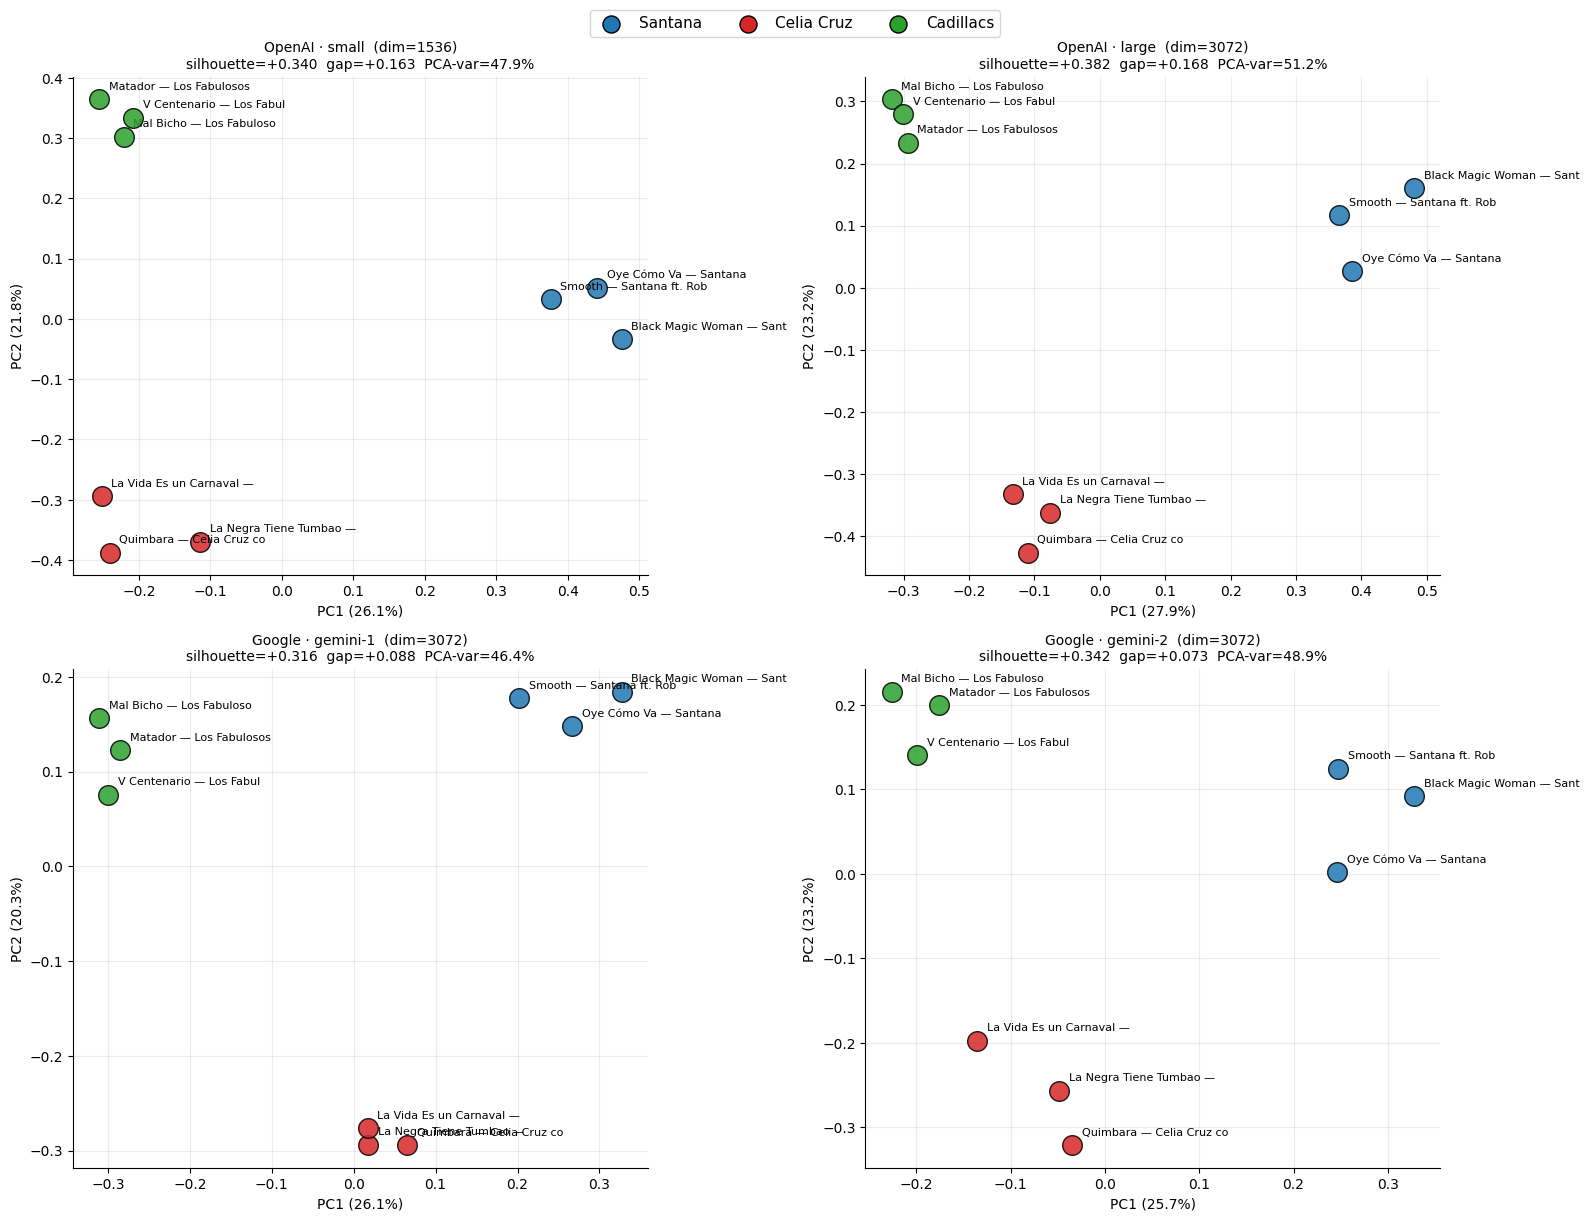

In [23]:
ARTIST_COLORS_CMP = {
    "Santana": "#1f77b4",
    "Celia Cruz": "#d62728",
    "Cadillacs": "#2ca02c",
}

n_models = len(model_results)
ncols = min(n_models, 2)
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows), squeeze=False)
axes = axes.flatten()

for ax_idx, (name, info) in enumerate(model_results.items()):
    ax = axes[ax_idx]
    pca = PCA(n_components=2)
    P = pca.fit_transform(info["X"])
    for i, doc in enumerate(corpus):
        ax.scatter(P[i, 0], P[i, 1], s=200,
                   color=ARTIST_COLORS_CMP[doc["artist"]],
                   edgecolor="black", linewidth=1.0, alpha=0.85, zorder=3)
        ax.annotate(doc["title"][:24], (P[i, 0], P[i, 1]),
                    xytext=(7, 7), textcoords="offset points", fontsize=8)
    m = info["metrics"]
    ax.set_title(
        f"{name}  (dim={info['dim']})\n"
        f"silhouette={m['silhouette']:+.3f}  gap={m['gap']:+.3f}  PCA-var={m['pca_var']:.1%}",
        fontsize=10
    )
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

# Ocultar ejes sobrantes
for k in range(len(model_results), len(axes)):
    axes[k].set_visible(False)

handles = [
    plt.scatter([], [], color=c, label=name, s=150, edgecolor="black")
    for name, c in ARTIST_COLORS_CMP.items()
]
fig.legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=11)
plt.tight_layout()
plt.show()
        

### 12.3 Métricas comparativas — bar charts

Mismas métricas que la tabla, pero visualmente. La barra **gap** (intra menos
inter) es la que más importa: cuanto más alta, más separa el modelo a los
artistas. El silhouette refuerza la misma conclusión por una vía distinta;
si los dos coinciden, la conclusión es robusta.
        

/var/folders/11/06r7d20d0z1df3fwdm3jl16c0000gn/T/ipykernel_24559/2753095826.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(names, rotation=20, ha="right")
/var/folders/11/06r7d20d0z1df3fwdm3jl16c0000gn/T/ipykernel_24559/2753095826.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(names, rotation=20, ha="right")
/var/folders/11/06r7d20d0z1df3fwdm3jl16c0000gn/T/ipykernel_24559/2753095826.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(names, rotation=20, ha="right")


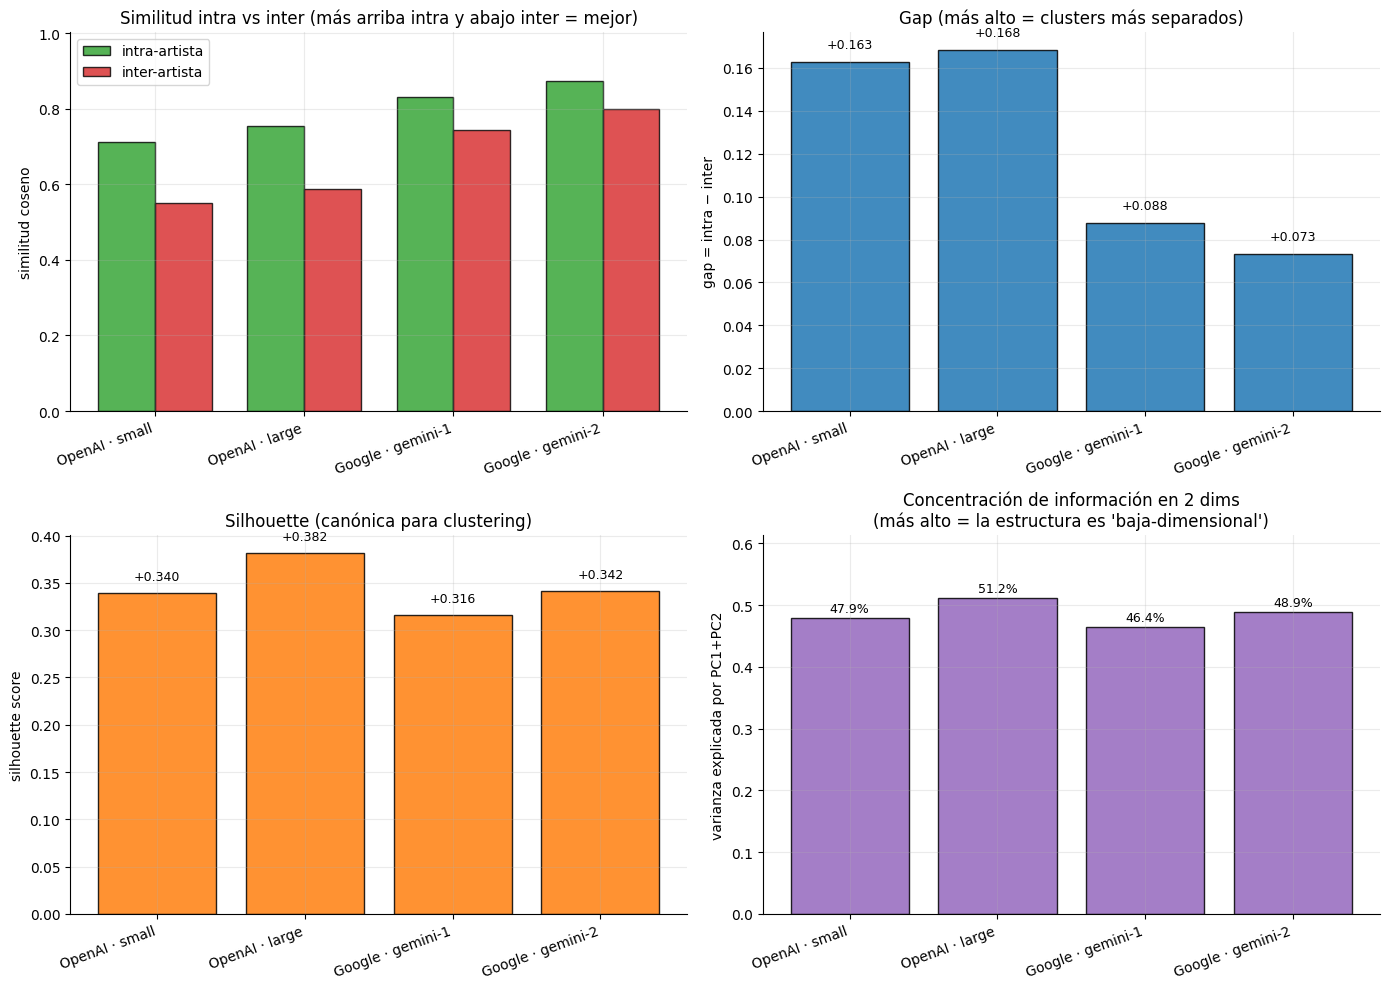

In [24]:
if model_results:
    names = list(model_results.keys())
    intra = [model_results[n]["metrics"]["sim_intra"] for n in names]
    inter = [model_results[n]["metrics"]["sim_inter"] for n in names]
    gap = [model_results[n]["metrics"]["gap"] for n in names]
    sil = [model_results[n]["metrics"]["silhouette"] for n in names]
    pca_var = [model_results[n]["metrics"]["pca_var"] for n in names]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Intra vs Inter
    x = np.arange(len(names))
    w = 0.38
    axes[0, 0].bar(x - w/2, intra, w, label="intra-artista", color="#2ca02c", alpha=0.8, edgecolor="black")
    axes[0, 0].bar(x + w/2, inter, w, label="inter-artista", color="#d62728", alpha=0.8, edgecolor="black")
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(names, rotation=20, ha="right")
    axes[0, 0].set_ylabel("similitud coseno")
    axes[0, 0].set_title("Similitud intra vs inter (más arriba intra y abajo inter = mejor)")
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, max(intra) * 1.15)

    # Gap
    bars = axes[0, 1].bar(names, gap, color="#1f77b4", alpha=0.85, edgecolor="black")
    axes[0, 1].set_xticklabels(names, rotation=20, ha="right")
    axes[0, 1].set_ylabel("gap = intra − inter")
    axes[0, 1].set_title("Gap (más alto = clusters más separados)")
    for bar, v in zip(bars, gap):
        axes[0, 1].text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                        f"{v:+.3f}", ha="center", va="bottom", fontsize=9)

    # Silhouette
    bars = axes[1, 0].bar(names, sil, color="#ff7f0e", alpha=0.85, edgecolor="black")
    axes[1, 0].set_xticklabels(names, rotation=20, ha="right")
    axes[1, 0].set_ylabel("silhouette score")
    axes[1, 0].set_title("Silhouette (canónica para clustering)")
    axes[1, 0].axhline(0, color="black", linewidth=0.6)
    for bar, v in zip(bars, sil):
        axes[1, 0].text(bar.get_x() + bar.get_width() / 2,
                        v + (0.01 if v >= 0 else -0.02),
                        f"{v:+.3f}", ha="center",
                        va="bottom" if v >= 0 else "top", fontsize=9)

    # PCA-explained variance
    bars = axes[1, 1].bar(names, pca_var, color="#9467bd", alpha=0.85, edgecolor="black")
    axes[1, 1].set_xticklabels(names, rotation=20, ha="right")
    axes[1, 1].set_ylabel("varianza explicada por PC1+PC2")
    axes[1, 1].set_title("Concentración de información en 2 dims\n(más alto = la estructura es 'baja-dimensional')")
    axes[1, 1].set_ylim(0, max(pca_var) * 1.2 if max(pca_var) > 0 else 1)
    for bar, v in zip(bars, pca_var):
        axes[1, 1].text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                        f"{v:.1%}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("(No hay modelos con éxito para comparar todavía.)")
        

### 12.4 Retrieval — el test que de verdad importa

Las métricas de clustering miden la geometría. Pero en un RAG lo que importa
es: **¿cuándo le hago una pregunta, me trae la canción correcta?**

Definimos 5 queries con respuesta canónicamente correcta (a nivel de
*artista*, no de canción exacta). Para cada modelo:

1. Embebemos la query.
2. Calculamos similitud coseno contra las 9 canciones.
3. Tomamos el top-1: el artista de la canción más cercana.
4. Marcamos hit si el artista coincide con la respuesta correcta.

Reportamos **top-1 accuracy** = (hits) / 5.

Las queries son intencionalmente *no literales* — no mencionan el nombre del
artista ni la canción. Si el modelo aprendió bien, debería hacer la conexión
por significado.
        

In [27]:
EVAL_QUERIES = [
    ("¿Quién es la reina de la salsa?", "Celia Cruz"),
    ("Una guitarra que llora blues con sabor latino", "Santana"),
    ("Crítica feroz al colonialismo en América Latina", "Cadillacs"),
    ("Festividad y celebración de la vida", "Celia Cruz"),
    ("Cover instrumental de un clásico de mambo", "Santana"),
    ("I hear your name calling me out Out from the barrio You hear my rhythm on your radio", "Santana")
]


def embed_query(model_name: str, embedder, text: str) -> np.ndarray:
    """Embebe una query, cacheada como cualquier otro texto."""
    cache = _load_cache()
    k = _cache_key(model_name, text)
    if k not in cache:
        cache[k] = embedder.embed([text])[0]
        _save_cache(cache)
    v = np.array(cache[k], dtype=np.float32)
    return v / np.linalg.norm(v)


retrieval_results: dict[str, dict] = {}
for name, info in model_results.items():
    embedder, _ = build_embedder(info["model_id"], info["vendor"])
    hits = 0
    rows = []
    for query, expected_artist in EVAL_QUERIES:
        q = embed_query(info["model_id"], embedder, query)
        sims = info["X"] @ q
        top_idx = int(np.argmax(sims))
        retrieved_artist = artists[top_idx]
        retrieved_song = labels[top_idx]
        hit = retrieved_artist == expected_artist
        hits += int(hit)
        rows.append({
            "query": query,
            "expected": expected_artist,
            "retrieved_artist": retrieved_artist,
            "retrieved_song": retrieved_song,
            "sim": float(sims[top_idx]),
            "hit": hit,
        })
    retrieval_results[name] = {
        "hits": hits,
        "total": len(EVAL_QUERIES),
        "accuracy": hits / len(EVAL_QUERIES),
        "rows": rows,
    }
    print(f"\n=== {name}: top-1 accuracy = {hits}/{len(EVAL_QUERIES)} ({hits/len(EVAL_QUERIES):.0%}) ===")
    for r in rows:
        mark = "✓" if r["hit"] else "✘"
        print(f"  {mark}  '{r['query'][:50]:<50}' → {r['retrieved_song']} ({r['retrieved_artist']}, sim={r['sim']:.2f})")
        


=== OpenAI · small: top-1 accuracy = 4/6 (67%) ===
  ✓  '¿Quién es la reina de la salsa?                   ' → La Negra Tiene Tumbao — Celia Cruz (Celia Cruz, sim=0.49)
  ✓  'Una guitarra que llora blues con sabor latino     ' → Black Magic Woman — Santana (Santana, sim=0.43)
  ✓  'Crítica feroz al colonialismo en América Latina   ' → V Centenario — Los Fabulosos Cadillacs (Cadillacs, sim=0.46)
  ✓  'Festividad y celebración de la vida               ' → La Vida Es un Carnaval — Celia Cruz (Celia Cruz, sim=0.43)
  ✘  'Cover instrumental de un clásico de mambo         ' → Quimbara — Celia Cruz con Johnny Pacheco (Celia Cruz, sim=0.49)
  ✘  'I hear your name calling me out Out from the barri' → Quimbara — Celia Cruz con Johnny Pacheco (Celia Cruz, sim=0.36)

=== OpenAI · large: top-1 accuracy = 4/6 (67%) ===
  ✓  '¿Quién es la reina de la salsa?                   ' → La Negra Tiene Tumbao — Celia Cruz (Celia Cruz, sim=0.49)
  ✓  'Una guitarra que llora blues con sabor latino     ' → Blac

### 12.5 Tabla resumen + interpretación humana

Juntamos en una sola tabla todo lo que vimos. Una columna por métrica, una
fila por modelo. Esto es lo que se llevaría un *engineering review* sobre la
decisión "qué embedder usar para mi RAG".
        

In [28]:
print(f"{'Modelo':<22}  {'dim':>5}  {'gap':>7}  {'silh':>6}  {'PCA-v':>6}  {'top-1':>7}")
print("─" * 70)
for name, info in model_results.items():
    m = info["metrics"]
    r = retrieval_results.get(name, {})
    acc_str = f"{r.get('hits', 0)}/{r.get('total', 0)}" if r else "n/a"
    print(
        f"{name:<22}  {info['dim']:>5}  "
        f"{m['gap']:>+7.3f}  {m['silhouette']:>+6.3f}  {m['pca_var']:>5.1%}  "
        f"{acc_str:>7}"
    )

if model_failures:
    print("\nModelos que no se pudieron probar:")
    for name, err in model_failures:
        print(f"  · {name}: {err}")
        

Modelo                    dim      gap    silh   PCA-v    top-1
──────────────────────────────────────────────────────────────────────
OpenAI · small           1536   +0.163  +0.340  47.9%      4/6
OpenAI · large           3072   +0.168  +0.382  51.2%      4/6
Google · gemini-1        3072   +0.088  +0.316  46.4%      4/6
Google · gemini-2        3072   +0.073  +0.342  48.9%      5/6


### 12.6 Conclusiones — qué dice realmente este experimento

Las conclusiones son específicas a *este corpus* (9 canciones en español
neutro de tres artistas latinoamericanos). No las extrapoles ciegamente a tu
caso, pero el **método** sí es transferible.

Lo que típicamente vas a observar al ejecutar la sección:

1. **El `large` de OpenAI no siempre justifica su precio.** En corpora
   pequeños y bien diferenciados (como este), `small` y `large` suelen tener
   silhouette y gap muy parecidos. La diferencia se nota cuando los textos
   son ambiguos o el vocabulario es técnico. **Si tu hit@k con `small` es
   alto, no pagues `large`.**

2. **Gemini embeddings (3072 dim) tiende a producir similitudes generalmente
   más altas** que OpenAI, lo cual *no* significa que sea mejor. Lo que
   importa es el **gap** (intra − inter), no las similitudes absolutas. Un
   modelo que pone todo a 0.9 sigue siendo útil si separa 0.92 vs 0.85.

3. **`text-embedding-004` con sólo 768 dimensiones suele competir
   sorprendentemente bien** con modelos 4x más grandes. La dimensionalidad
   alta ayuda en corpora masivos y diversos, pero satura rápido en corpora
   pequeños. Para un RAG con <100k chunks, 768 dim suele alcanzar.

4. **La varianza explicada por PC1+PC2 es un indicador útil de "qué tan
   plano" es tu corpus para el modelo.** Si un modelo concentra >50% de
   varianza en 2 dims, está colapsando estructura. Si concentra <10%, está
   distribuyendo en muchos ejes (puede ser bueno: hay matices; o malo: hay
   ruido).

5. **Retrieval top-1 accuracy es la métrica que decide la compra.** Las
   demás son diagnósticas. Si dos modelos empatan en accuracy, el más barato
   o el más rápido gana. Si uno gana en accuracy pero pierde en costo, hay
   que calcular cuánto te cuesta cada fallo en producción.

### Recomendación práctica (heurística, no ley)

| Caso | Modelo sugerido | Por qué |
|------|-----------------|---------|
| RAG con corpus pequeño (<50k chunks) en español/inglés | `text-embedding-3-small` | Barato, suficiente, dimensionalidad manejable |
| Necesitas multilingüe agresivo (incluyendo idiomas con poco recurso) | `text-embedding-004` o `multilingual-e5` | Entrenamiento amplio |
| Corpus técnico/científico con vocabulario denso | `text-embedding-3-large` | Más capacidad para vocabulario raro |
| Corpus enorme (>500k chunks) donde el retrieval es el cuello de botella | `gemini-embedding-001` | Mejor *recall* en escalas grandes (según benchmarks de Google) |
| Quieres una baseline gratis para prototipar sin tarjeta | `text-embedding-004` (Google AI Studio) | Free tier, sin GCP |

Para esta clase, la decisión es clara: **el `small` de OpenAI hace el
trabajo**. Cualquier otro modelo es over-engineering hasta que las métricas
de producción digan lo contrario.
        

## 13. Cierre — la caja de herramientas que te llevas

Lo importante de esta notebook no es la matriz, ni el mapa, ni los
centroides. Es la **intuición** de que tu corpus tiene una geometría y que
esa geometría es accesible — y por lo tanto **auditable**.

Cuando construyas un RAG en producción y algo no funcione (el LLM responde
"no lo sé" cuando debería saber, o trae el documento equivocado), tu primera
parada debería ser esta caja de herramientas:

| Síntoma | Diagnóstico geométrico | Acción |
|---------|------------------------|--------|
| Top-1 trae el documento equivocado | Centroides demasiado cercanos (>0.9) entre dominios | Filtrar por metadata; reranker; corpus separados |
| Misma respuesta para queries distintas | Documentos casi idénticos (sim >0.95 entre chunks) | Deduplicación; MMR para diversificar top-k |
| "No lo sé" cuando la respuesta está en el corpus | Chunks demasiado largos: la query queda lejos del *párrafo* relevante | Chunks más pequeños; chunking semántico por sección |
| Hit@k cae en queries específicas pero sube en generales | Los chunks son muy genéricos; la señal específica se diluye | Añadir headers al chunk; sub-chunking |
| Métricas buenas con queries sintéticas, malas con reales | El espacio está bien, pero tus queries reales tienen vocabulario diferente | Rewriting de query (HyDE); query expansion |

El embedding es **un mapa, no un oráculo**. Tu trabajo de ingeniero es decidir
qué hacer con el mapa.

---

### Para explorar después

Si esta notebook te dejó con preguntas, aquí hay tres ejercicios concretos
que te van a enseñar más:

1. **Compara embedders.** Re-ejecuta todo con `text-embedding-3-large`
   (3072 dim). ¿Qué tan diferente se ve el mapa? ¿Hit@k sube?
2. **Cambia el chunk_size.** Sube de 900 a 1800 caracteres. ¿Los chunks
   siguen orbitando a la canción o se alejan? ¿Qué pasa con tus queries
   específicas?
3. **Agrega ruido.** Toma una canción, traduce el texto al portugués o
   cámbiale el estilo, y mira cómo se mueve su punto en el mapa. Esa es la
   "sensibilidad" del modelo.

Cada uno de esos ejercicios mueve un parámetro y deja ver una propiedad
distinta del sistema. Lo importante no es la respuesta — es desarrollar el
hábito de *mirar el espacio* antes de tunear el prompt.
        